# Footprint Matching Geometry & PSF -- Demonstration

This notebook demonstrates the two new footprint-matching modules:

- **`libera_utils.footprint_matching.psf`** -- the (partial) CERES point spread
  function and its 95%-energy angular extent.
- **`libera_utils.footprint_matching.geometry`** -- turning an L1B footprint's
  geolocation and viewing zenith angle into a latitude/longitude **bounding box**
  of the patch of Earth the radiometer is sensing.

The bounding box is what tells the tile manager which ancillary-data tiles to load
for each radiometer footprint. It must always *enclose* the footprint (a safe
superset), so the geometry deliberately rounds outward.

> **Note on the current implementation**: the PSF is the heritage **CERES** PSF
> (the Libera PSF is not yet delivered) and the Earth is approximated as a
> **sphere**. Both choices are flagged with `TODO`s in the source for future work.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

from libera_utils.footprint_matching import geometry as geo
from libera_utils.footprint_matching import psf
from libera_utils.footprint_matching.geometry import OffLimbError, compute_footprint_bounding_box

%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 5)

## 1. The Point Spread Function (`psf.py`)

The PSF describes how the radiometer weights radiance across its field of view.
It is defined in the instrument **angular frame**: along-scan angle $\delta$ and
cross-scan angle $\beta$. Two features matter for footprint matching:

1. it is **symmetric across the cross-scan axis**, $P(\delta,\beta)=P(\delta,-\beta)$, and
2. it is **asymmetric along-scan** -- the detector's thermal response leaves a
   trailing tail (CERES ATBD Eq. 4.4-2).


95% energy extent (deg): PSFAngularExtent(delta_back_deg=1.2399999999999984, delta_front_deg=1.3400000000000034, beta_max_deg=1.2600000000000025)
conservative along-scan half-extent: 1.3400000000000034
static 1-deg FOV extent          : PSFAngularExtent(delta_back_deg=1.0, delta_front_deg=1.0, beta_max_deg=1.0)


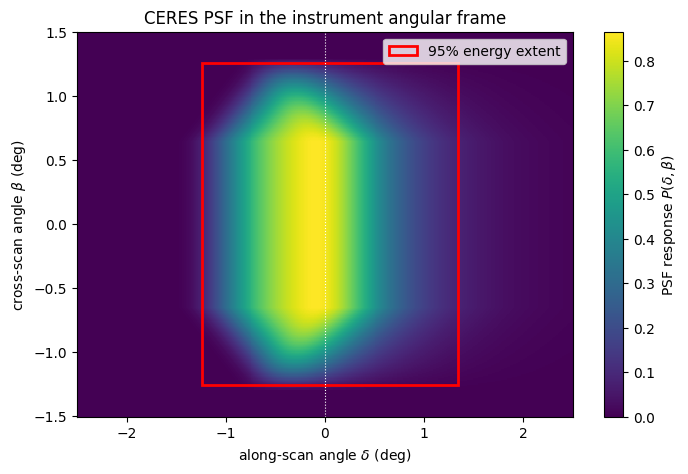

In [2]:
# Evaluate the CERES PSF on a regular angular grid.
delta = np.linspace(-2.5, 2.5, 500)
beta = np.linspace(-1.5, 1.5, 300)
DD, BB = np.meshgrid(delta, beta)
P = psf.psf_weight(DD, BB)

# The 95%-energy angular extent that the bounding box is built from.
ext = psf.psf_95_energy_extent()
print("95% energy extent (deg):", ext)
print("conservative along-scan half-extent:", psf.conservative_along_scan_extent(ext))
print("static 1-deg FOV extent          :", psf.static_fov_extent())

fig, ax = plt.subplots()
mesh = ax.pcolormesh(delta, beta, P, shading="auto", cmap="viridis")
fig.colorbar(mesh, ax=ax, label="PSF response $P(\\delta,\\beta)$")
# Overlay the 95%-energy extent rectangle (asymmetric in delta).
ax.add_patch(
    Rectangle(
        (-ext.delta_back_deg, -ext.beta_max_deg),
        ext.delta_back_deg + ext.delta_front_deg,
        2 * ext.beta_max_deg,
        fill=False,
        edgecolor="red",
        lw=2,
        label="95% energy extent",
    )
)
ax.axvline(0, color="w", ls=":", lw=0.8)
ax.set_xlabel("along-scan angle $\\delta$ (deg)")
ax.set_ylabel("cross-scan angle $\\beta$ (deg)")
ax.set_title("CERES PSF in the instrument angular frame")
ax.legend(loc="upper right")
plt.show()

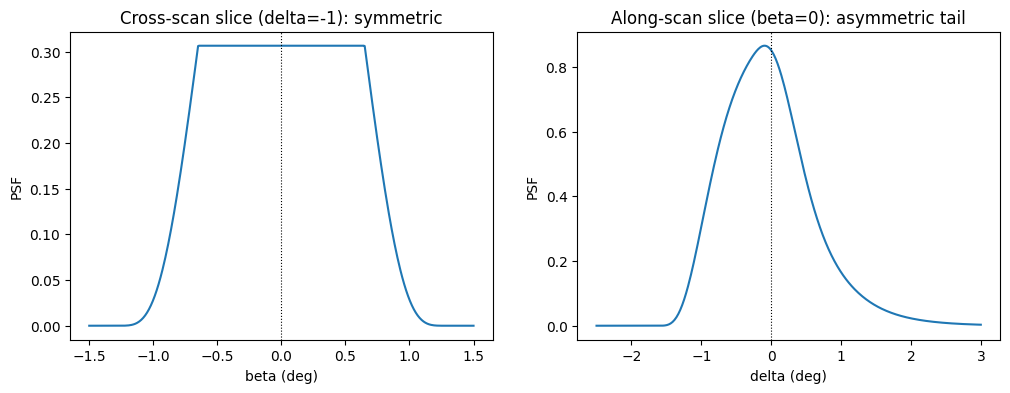

In [3]:
# Cross-scan symmetry vs along-scan asymmetry, shown as 1-D slices.
fig, (axc, axa) = plt.subplots(1, 2, figsize=(12, 4))

b = np.linspace(-1.5, 1.5, 400)
axc.plot(b, psf.psf_weight(-1.0, b))
axc.set_title("Cross-scan slice (delta=-1): symmetric")
axc.set_xlabel("beta (deg)")
axc.set_ylabel("PSF")
axc.axvline(0, color="k", ls=":", lw=0.8)

d = np.linspace(-2.5, 3.0, 400)
axa.plot(d, psf.psf_weight(d, 0.0))
axa.set_title("Along-scan slice (beta=0): asymmetric tail")
axa.set_xlabel("delta (deg)")
axa.set_ylabel("PSF")
axa.axvline(0, color="k", ls=":", lw=0.8)
plt.show()

## 2. From viewing angle to ground distance

A *fixed* angular extent at the satellite projects to a *growing* ground distance
as the viewing zenith angle (VZA) increases toward the limb. The geometry module
solves the satellite/Earth-centre/ground-point triangle and projects the PSF's
angular extent into along-scan and cross-scan ground half-extents (km).

Below we use the module's internal helpers to show the footprint *full width*
growing with VZA. Compare with CERES ATBD Table 4.4-1 (e.g. ~328 x 82 km at
VZA=75 deg) -- our along-scan is intentionally larger because the bounding box is a
conservative symmetric superset.

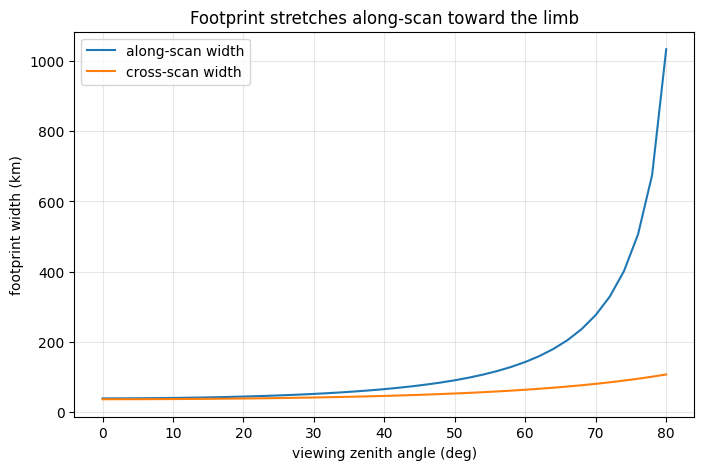

VZA= 0 deg -> along ~  39.1 km, cross ~ 36.7 km
VZA=70 deg -> along ~ 276.6 km, cross ~ 80.6 km
VZA=75 deg -> along ~ 448.4 km, cross ~ 92.4 km


In [4]:
R = geo.EARTH_RADIUS_KM
alt = geo.NOMINAL_ALTITUDE_KM
along_ext = psf.conservative_along_scan_extent(ext)
cross_ext = ext.beta_max_deg


def ground_widths_km(vza):
    """Full along/cross footprint width (km) at a given VZA."""
    alpha, rho, reh = geo._solve_viewing_triangle(0, 0, 0, 0, vza, alt, R)
    along = 2 * geo._along_scan_ground_extent_km(alpha, along_ext, reh, R)
    cross = 2 * geo._cross_scan_ground_extent_km(rho, cross_ext)
    return along, cross


# Sweep only the on-Earth range; beyond ~81 deg the box corner crosses the limb
# (PartialFootprintError -- see section 4).
vzas = np.arange(0, 81, 2.0)
along_km, cross_km = np.array([ground_widths_km(v) for v in vzas]).T

fig, ax = plt.subplots()
ax.plot(vzas, along_km, label="along-scan width")
ax.plot(vzas, cross_km, label="cross-scan width")
ax.set_xlabel("viewing zenith angle (deg)")
ax.set_ylabel("footprint width (km)")
ax.set_title("Footprint stretches along-scan toward the limb")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

for vza in (0, 70, 75):
    along, cross = ground_widths_km(vza)
    print(f"VZA={vza:2d} deg -> along ~{along:6.1f} km, cross ~{cross:5.1f} km")

## 3. Bounding boxes

`compute_footprint_bounding_box` is the public entry point. It takes the L1B fields
that are actually populated -- footprint lat/lon, subsatellite lat/lon, and VZA --
and returns a `BoundingBox`. Here we place a footprint at the equator with the
subsatellite point due north, so the along-scan axis runs north-south, and draw the
boxes for increasing VZA.

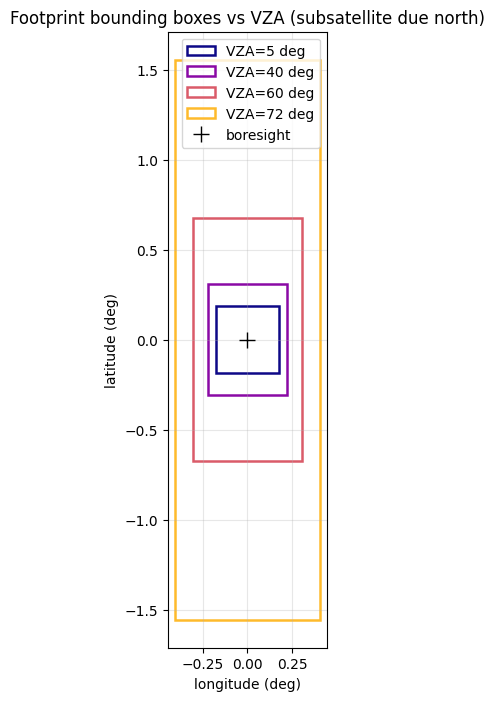

In [5]:
def draw_box(ax, bb, **kw):
    """Draw a BoundingBox as a rectangle (handles the >180 dateline form)."""
    width = bb.lon_max - bb.lon_min
    ax.add_patch(Rectangle((bb.lon_min, bb.lat_min), width, bb.lat_max - bb.lat_min, fill=False, lw=1.8, **kw))


fig, ax = plt.subplots(figsize=(7, 8))
colors = plt.cm.plasma(np.linspace(0, 0.85, 4))
for vza, c in zip((5, 40, 60, 72), colors):
    # subsatellite point north of the footprint; larger VZA -> further north.
    bb = compute_footprint_bounding_box(0.0, 0.0, vza / 10.0, 0.0, vza, altitude_km=alt)
    draw_box(ax, bb, edgecolor=c, label=f"VZA={vza} deg")
ax.plot(0, 0, "k+", ms=12, label="boresight")
ax.set_xlabel("longitude (deg)")
ax.set_ylabel("latitude (deg)")
ax.set_title("Footprint bounding boxes vs VZA (subsatellite due north)")
ax.legend()
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.show()

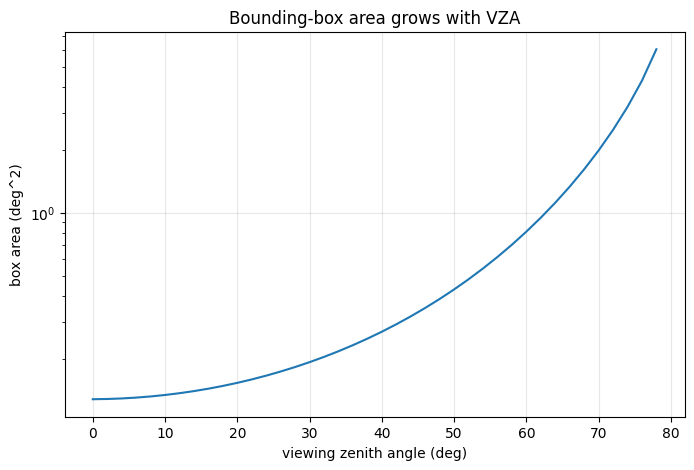

In [6]:
# Box area grows rapidly with VZA.
vza_scan = np.arange(0, 80, 2.0)
areas = []
for vza in vza_scan:
    bb = compute_footprint_bounding_box(0.0, 0.0, max(vza / 10.0, 0.01), 0.0, vza, altitude_km=alt)
    areas.append((bb.lat_max - bb.lat_min) * (bb.lon_max - bb.lon_min))
plt.plot(vza_scan, areas)
plt.xlabel("viewing zenith angle (deg)")
plt.ylabel("box area (deg^2)")
plt.title("Bounding-box area grows with VZA")
plt.grid(alpha=0.3)
plt.yscale("log")
plt.show()

## 4. Edge cases

The module handles the structural hard cases explicitly:

- **pole enclosure** -- the box spans all longitudes and pins latitude to +/-90;
- **dateline crossing** -- represented with `lon_max > 180` and `wraps_dateline=True`;
- **off-limb** -- the centroid view misses the Earth (VZA >= 90 deg) -> `OffLimbError`;
- **severe-angle truncation** -- boresight on Earth but a box *corner* off it -> box truncated at the horizon and flagged via `bbox.truncated` (or `PartialFootprintError` with `on_limb='raise'`);
- **fill / NaN inputs** (non-Earth views) -- raise `OffLimbError`.


In [7]:
# Pole enclosure
bb_pole = compute_footprint_bounding_box(89.9, 0.0, 88.0, 0.0, 60.0, altitude_km=alt)
print("near N pole :", bb_pole)

# Dateline crossing
bb_dl = compute_footprint_bounding_box(0.0, 179.8, 0.0, 178.0, 70.0, altitude_km=alt)
print("dateline    :", bb_dl, "\n   wraps_dateline =", bb_dl.wraps_dateline)

# Off-limb: when even the centroid misses the Earth (VZA >= 90 deg) there is no
# footprint at all, so OffLimbError is raised regardless of on_limb.
try:
    compute_footprint_bounding_box(0.0, 0.0, 30.0, 0.0, 90.0, altitude_km=alt)
except OffLimbError as e:
    print("centroid off-limb raised:", e)

# Fill-valued (non-Earth) footprint
try:
    compute_footprint_bounding_box(-999.0, -999.0, 10.0, 0.0, -999.0, altitude_km=alt)
except OffLimbError as e:
    print("fill raised    :", e)

near N pole : BoundingBox(lat=[89.2252546121813, 90.0], lon=[-180.0, 180.0], wraps_dateline=False, is_polar=True, truncated=False)
dateline    : BoundingBox(lat=[-0.380603631504107, 0.380603631504107], lon=[178.49308858687596, 181.10691141312407], wraps_dateline=True, is_polar=False, truncated=False) 
   wraps_dateline = True
centroid off-limb raised: Cone angle 62.136 deg reaches the Earth limb (62.136 deg); the line of sight misses the surface.
fill raised    : Footprint has fill/non-finite geolocation (non-Earth view).


### Severe-angle truncation: partial coverage

At very large viewing zenith angles the footprint stretches so far that the
limb-ward **corner** of its bounding box reaches past the Earth's horizon -- even
though the boresight, and the pure along-scan and cross-scan edges, are still on
Earth. This is detected in the angular domain (the corner's effective cone angle
vs the Earth's angular radius). **By default** the box is truncated at the horizon
and marked `bbox.truncated = True` (partial coverage) -- following the CERES
convention of flagging, not discarding, partially covered footprints. Callers that
want a hard error can pass `on_limb='raise'` to get a `PartialFootprintError`
(a subclass of `OffLimbError`).

In [8]:
from libera_utils.footprint_matching.geometry import PartialFootprintError

# VZA = 85 deg: centroid cone angle ~61 deg (< limb ~62 deg) so the boresight is
# on Earth, but the box corner (max along-scan toward the limb + max cross-scan)
# crosses the horizon.
#
# Default policy ('flag'): the box is truncated at the horizon and flagged -- no
# exception is raised.
bb = compute_footprint_bounding_box(0.0, 0.0, 8.5, 0.0, 85.0, altitude_km=alt)
print("default (flag) -> truncated =", bb.truncated)
print("   ", bb)

# Opt in to strict behaviour with on_limb='raise'.
try:
    compute_footprint_bounding_box(0.0, 0.0, 8.5, 0.0, 85.0, altitude_km=alt, on_limb="raise")
except PartialFootprintError as e:
    print('\non_limb="raise" -> PartialFootprintError:')
    print("   ", e)

# PartialFootprintError is a subclass of OffLimbError, so existing handlers catch it.
print("\nissubclass(PartialFootprintError, OffLimbError) =", issubclass(PartialFootprintError, OffLimbError))

default (flag) -> truncated = True
    BoundingBox(lat=[-4.128008410152888, 4.128008410152888], lon=[-0.5936562749370751, 0.5936562749370751], wraps_dateline=False, is_polar=False, truncated=True)

on_limb="raise" -> PartialFootprintError:
    Bounding-box corner reaches cone angle 63.073 deg (Earth limb 62.136 deg) at centroid cone angle 61.726 deg: part of the box is off the Earth limb. The default on_limb='flag' truncates the box at the horizon and marks it as partial coverage instead of raising.

issubclass(PartialFootprintError, OffLimbError) = True


## 5. Real L1B data

Finally, run the module on the example L1B file. In this product version the
`Altitude` and `Cone_Angle` fields are not populated, so the geometry is driven
entirely by VZA + footprint/subsatellite positions (the altitude is recovered
internally). We pick footprints across a range of VZA and draw their boxes on the
ground track. (Cell is skipped if the example file is not present.)

In [9]:
import pathlib

l1b = pathlib.Path("external_data/L1B/LIBERA_L1B_RAD-4CH_V0-5-5_20280212T033945_20280212T052007_R26154153835.nc")
if not l1b.exists():
    print("example L1B file not available -- skipping")
else:
    import netCDF4 as nc

    ds = nc.Dataset(l1b)

    def field(name):
        v = ds.variables[name]
        a = np.array(v[:], dtype=float)
        if hasattr(v[:], "mask"):
            a[np.ma.getmaskarray(v[:])] = np.nan
        return a

    lat, lon = field("Latitude"), field("Longitude")
    sslat, sslon = field("Subsatellite_Latitude"), field("Subsatellite_Longitude")
    vza = field("Viewing_Zenith_Surface")
    ds.close()

    # A short contiguous slice of Earth-view footprints (one scan).
    earth = np.where(np.isfinite(lat) & np.isfinite(vza))[0]
    seg = earth[(earth >= earth[0] + 1000) & (earth < earth[0] + 1240)]

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.plot(lon[seg], lat[seg], ".", ms=2, color="0.6", label="footprint centroids")
    # Draw boxes for a few footprints spanning the VZA range in this segment.
    order = seg[np.argsort(vza[seg])]
    picks = order[:: max(1, len(order) // 6)][:6]
    for i in picks:
        try:
            bb = compute_footprint_bounding_box(lat[i], lon[i], sslat[i], sslon[i], vza[i])
        except OffLimbError:
            continue
        draw_box(ax, bb, edgecolor="C0")
        ax.annotate(f"{vza[i]:.0f}", (lon[i], lat[i]), fontsize=8, color="C3")
    ax.set_xlabel("longitude (deg)")
    ax.set_ylabel("latitude (deg)")
    ax.set_title("Bounding boxes on real L1B footprints (labels = VZA in deg)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

    print(f"computed boxes for footprints with VZA {np.nanmin(vza[seg]):.1f}..{np.nanmax(vza[seg]):.1f} deg")

example L1B file not available -- skipping


## Summary

- `psf.psf_weight` / `psf_95_energy_extent` give the CERES PSF and its 95% angular
  reach; the along-scan extent is asymmetric, the cross-scan extent symmetric.
- `geometry.compute_footprint_bounding_box` projects that reach onto the surface,
  growing strongly with VZA, and returns a safe lat/lon superset with correct
  handling of curvature, poles, the dateline, and off-limb geometry.

**Future work** (see `TODO`s in the source): the full `PSFEngine` and the
Libera-specific PSF/FOV (`LIBSDC-601`), the forward per-pixel `(delta, beta)`
transform, vectorization over all footprints, and a WGS84 ellipsoid Earth model.